### Logistic Regression from Scratch
Binary classification using gradient descent (no model class from ML libraries).

### Steps
1. Load binary dataset and split train/test.
2. Standardize features (fit on train, transform both).
3. Initialize weights and bias to zeros.
4. Compute loss(Binary Cross Entropy)
5. Run gradient descent for 1000 iterations.
6. Predict probabilities with sigmoid and classes.
7. Compute accuracy, precision, recall,confusion matrix, Plot ROC Curve and F1.
8. Compare with sklearn.LogisticRegression


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

In [10]:
# Load dataset into pandas for readability
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print('DataFrame shape:', df.shape)
print('Class distribution:')
print(df['target'].value_counts().sort_index())
df.head()

DataFrame shape: (569, 31)
Class distribution:
target
0    212
1    357
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [11]:
# Train/test split and standardization from scratch
X = df.drop(columns='target').to_numpy(dtype=float)
y = df['target'].to_numpy(dtype=int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std = np.where(std == 0, 1, std)

X_train_std = (X_train - mean) / std
X_test_std = (X_test - mean) / std

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (455, 30) Test shape: (114, 30)


In [12]:
# Logistic Regression from scratch
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def compute_loss(y_true, y_prob):
    eps = 1e-12
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

def fit_logistic_regression(X, y, lr=0.05, n_iters=1000):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0
    losses = []

    for i in range(n_iters):
        linear = X @ w + b
        y_prob = sigmoid(linear)

        dw = (1 / n_samples) * (X.T @ (y_prob - y))
        db = (1 / n_samples) * np.sum(y_prob - y)

        w -= lr * dw
        b -= lr * db

        if i % 50 == 0:
            losses.append(compute_loss(y, y_prob))

    return w, b, losses

def predict_proba(X, w, b):
    return sigmoid(X @ w + b)

def predict(X, w, b, threshold=0.5):
    return (predict_proba(X, w, b) >= threshold).astype(int)

In [13]:
# Train and evaluate
w, b, losses = fit_logistic_regression(X_train_std, y_train, lr=0.05, n_iters=1000)

y_prob = predict_proba(X_test_std, w, b)
y_pred = predict(X_test_std, w, b)
cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")
print("Confusion Matrix:\
", cm)

Accuracy : 0.9737
Precision: 0.9859
Recall   : 0.9722
F1 Score : 0.9790
ROC AUC  : 0.9957
Confusion Matrix: [[41  1]
 [ 2 70]]


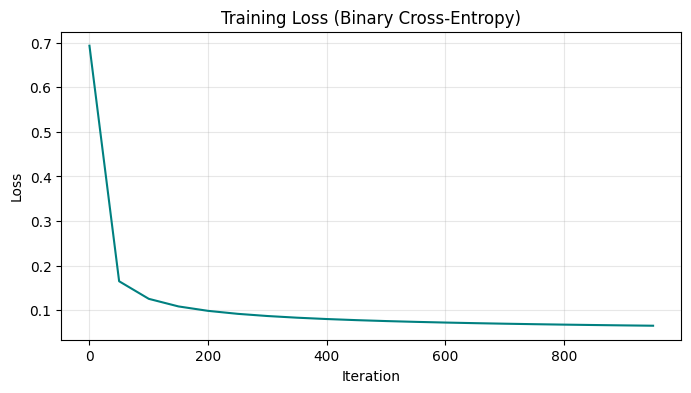

In [14]:
# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(losses)) * 50, losses, color='teal')
plt.title('Training Loss (Binary Cross-Entropy)')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.show()

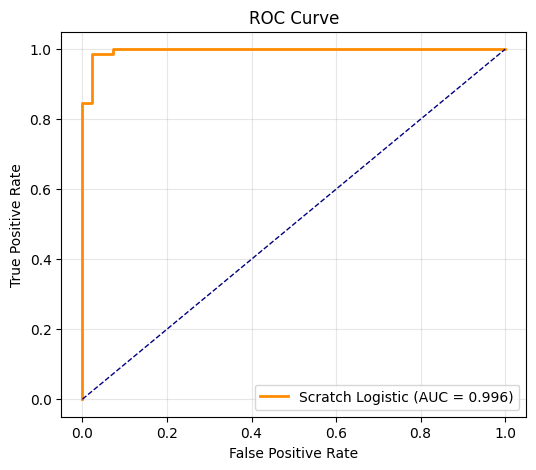

In [15]:
# ROC curve (from-scratch model)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Scratch Logistic (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

Scratch vs sklearn LogisticRegression
Scratch Accuracy : 0.9737 | sklearn Accuracy : 0.9825
Scratch Precision: 0.9859 | sklearn Precision: 0.9861
Scratch Recall   : 0.9722 | sklearn Recall   : 0.9861
Scratch F1 Score : 0.9790 | sklearn F1 Score : 0.9861
Scratch ROC AUC  : 0.9957 | sklearn ROC AUC  : 0.9954

Scratch Confusion Matrix:
 [[41  1]
 [ 2 70]]
sklearn Confusion Matrix:
 [[41  1]
 [ 1 71]]


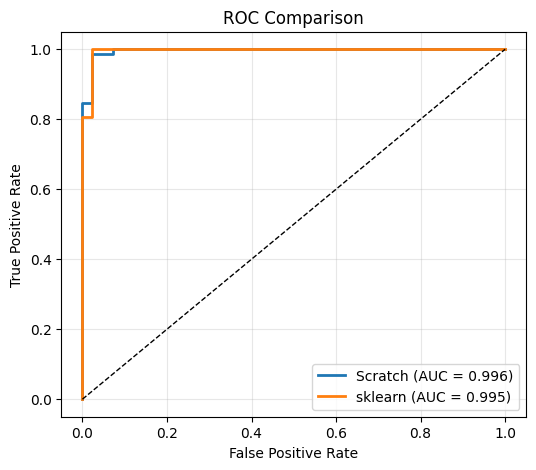

In [16]:
# Compare with sklearn LogisticRegression
sk_model = LogisticRegression(max_iter=1000, solver='lbfgs')
sk_model.fit(X_train_std, y_train)

sk_y_prob = sk_model.predict_proba(X_test_std)[:, 1]
sk_y_pred = sk_model.predict(X_test_std)
sk_cm = confusion_matrix(y_test, sk_y_pred)
sk_fpr, sk_tpr, _ = roc_curve(y_test, sk_y_prob)
sk_roc_auc = auc(sk_fpr, sk_tpr)

print('Scratch vs sklearn LogisticRegression')
print(f'Scratch Accuracy : {accuracy_score(y_test, y_pred):.4f} | sklearn Accuracy : {accuracy_score(y_test, sk_y_pred):.4f}')
print(f'Scratch Precision: {precision_score(y_test, y_pred):.4f} | sklearn Precision: {precision_score(y_test, sk_y_pred):.4f}')
print(f'Scratch Recall   : {recall_score(y_test, y_pred):.4f} | sklearn Recall   : {recall_score(y_test, sk_y_pred):.4f}')
print(f'Scratch F1 Score : {f1_score(y_test, y_pred):.4f} | sklearn F1 Score : {f1_score(y_test, sk_y_pred):.4f}')
print(f'Scratch ROC AUC  : {roc_auc:.4f} | sklearn ROC AUC  : {sk_roc_auc:.4f}')
print('\nScratch Confusion Matrix:\n', cm)
print('sklearn Confusion Matrix:\n', sk_cm)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'Scratch (AUC = {roc_auc:.3f})')
plt.plot(sk_fpr, sk_tpr, lw=2, label=f'sklearn (AUC = {sk_roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [17]:
# What if feature values are in very different ranges (no standardization)?
w_raw, b_raw, losses_raw = fit_logistic_regression(X_train, y_train, lr=0.05, n_iters=1000)
y_prob_raw = predict_proba(X_test, w_raw, b_raw)
y_pred_raw = predict(X_test, w_raw, b_raw)

raw_acc = accuracy_score(y_test, y_pred_raw)
raw_prec = precision_score(y_test, y_pred_raw)
raw_rec = recall_score(y_test, y_pred_raw)
raw_f1 = f1_score(y_test, y_pred_raw)
raw_fpr, raw_tpr, _ = roc_curve(y_test, y_prob_raw)
raw_auc = auc(raw_fpr, raw_tpr)

print('Without standardization (same lr, same iterations):')
print(f'Accuracy : {raw_acc:.4f}')
print(f'Precision: {raw_prec:.4f}')
print(f'Recall   : {raw_rec:.4f}')
print(f'F1 Score : {raw_f1:.4f}')
print(f'ROC AUC  : {raw_auc:.4f}')
print(f'Final BCE Loss (scaled): {losses[-1]:.6f}')
print(f'Final BCE Loss (raw)   : {losses_raw[-1]:.6f}')

Without standardization (same lr, same iterations):
Accuracy : 0.9386
Precision: 0.9333
Recall   : 0.9722
F1 Score : 0.9524
ROC AUC  : 0.9319
Final BCE Loss (scaled): 0.065167
Final BCE Loss (raw)   : 2.368375
